In [187]:
import h5py
import numpy as np

In [188]:
# load DDA result file
h5 = h5py.File("dda_results/pcas_ocbs_simulated_data.hdf5", "r")

In [189]:
# load sweep parameters
wl_m_m_pairs  = h5['target']['wl_m_m_pairs'][:]   # (N_pairs, 2): [wl_0, m_m]
m_p_xyz_list  = h5['target']['m_p_xyz_list'][:]   # (N_mp, 3)

In [190]:
# RMS noises of measured ReS and ImS values in this PCAS instrument
ReS_rms = 0.0043  # [um]
ImS_rms = 0.0030  # [um]

In [ ]:
# ── select condition and particle sizes ───────────────────────────────────────
# Change i_pair, i_mp, ind_bc/ab/gre to select the sweep condition.
# Add or remove indices in ind_rv_list to control which particle sizes are plotted.
i_pair = 0            # index into wl_m_m_pairs
i_mp   = 0            # index into m_p_xyz_list
ind_bc_ratio_list = 0
ind_ab_ratio_list = 0
ind_gre_beta_list = 0

ind_rv_list = [0, 1, 2, 3]  # r_v_base indices to load; extend freely (e.g. [0,1,2,3])

data_list = []        # list of dicts, one per particle size

for ind_rv in ind_rv_list:
    idx = (i_pair, i_mp, ind_rv, ind_bc_ratio_list, ind_ab_ratio_list, ind_gre_beta_list)

    S_fw_theta = h5['target']['simulated_data']['S_fw_PCAS_theta'][idx + (slice(None),)]
    S_fw_phi   = h5['target']['simulated_data']['S_fw_PCAS_phi'  ][idx + (slice(None),)]
    S_fw_mie   = h5['target']['simulated_data']['S_fw_PCAS_mie'  ][idx]
    r_ve       = float(h5['target']['simulated_data']['r_ve'][ind_rv, ind_bc_ratio_list, ind_ab_ratio_list, ind_gre_beta_list])
    euler      = h5['target']['simulated_data']['Euler_angles'][idx]

    spol = S_fw_theta
    ppol = S_fw_phi

    ReS_mean = (spol.real + ppol.real) / 2
    ImS_mean = (spol.imag + ppol.imag) / 2

    ReS_depol = (spol.real - ppol.real) / (spol.real + ppol.real)
    ImS_depol = (spol.imag - ppol.imag) / (spol.imag + ppol.imag)
    ReS_depol_rms  = np.sqrt((1 + ReS_depol**2) / 2) * ReS_rms / np.abs(ReS_mean)
    ImS_depol_rms  = np.sqrt((1 + ImS_depol**2) / 2) * ImS_rms / np.abs(ImS_mean)
    ReS_depol_SNR  = ReS_depol / ReS_depol_rms
    ImS_depol_SNR  = ImS_depol / ImS_depol_rms
    Tot_depol_SNR2 = ReS_depol_SNR**2 + ImS_depol_SNR**2

    data_list.append({
        'ind_rv':         ind_rv,
        'r_ve':           r_ve,
        'S_fw_mie':       S_fw_mie,
        'ReS_mean':       ReS_mean,
        'ImS_mean':       ImS_mean,
        'ReS_depol_SNR':  ReS_depol_SNR,
        'ImS_depol_SNR':  ImS_depol_SNR,
        'Tot_depol_SNR2': Tot_depol_SNR2,
        'Euler_angles':   euler,
    })

    print(f"  ind_rv={ind_rv}  r_ve={r_ve:.4f} um  (diameter {r_ve*2:.4f} um)")

  ind_rv=0  r_ve=0.0999 um  (diameter 0.1998 um)
  ind_rv=1  r_ve=0.2027 um  (diameter 0.4055 um)
  ind_rv=2  r_ve=0.3065 um  (diameter 0.6129 um)
  ind_rv=3  r_ve=0.4095 um  (diameter 0.8190 um)


In [192]:
from analytical_scattering_theories.homogeneous_sphere import mie_compute_q_and_s

wl_0    = wl_m_m_pairs[i_pair, 0]   # vacuum wavelength [um]
m_m     = wl_m_m_pairs[i_pair, 1]   # medium refractive index
m_p_xyz = m_p_xyz_list[i_mp]        # particle refractive index (x,y,z)
m_p_avg = np.mean(m_p_xyz)          # isotropic average for Mie reference

r_p_arr      = np.linspace(0.05, 1.2, 200)
S_fw_mie_arr = np.zeros(200, dtype=np.complex64)

for i, r_p in enumerate(r_p_arr):
    Qsca, Qabs, Qext, S_fw_mie_arr[i], _ = mie_compute_q_and_s(wl_0, m_m, r_p, m_p_avg, nang=3)

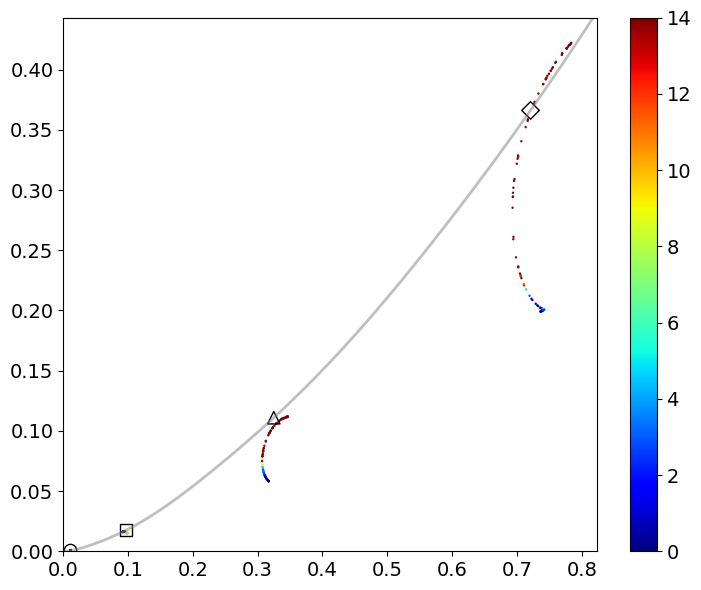

In [193]:
import matplotlib.pyplot as plt

# marker styles for Mie reference points (one per particle size)
mie_markers = ['o', 's', '^', 'D', 'v', 'p', 'h']

fig, axs = plt.subplots(1, 1, figsize=(7.5, 6))

size = 0.5
color_scale_max = 14
cbar_src = None

all_ReS = []
all_ImS = []

for i, d in enumerate(data_list):
    sc = axs.scatter(d['ReS_mean'], d['ImS_mean'],
                     c=d['Tot_depol_SNR2'], cmap='jet',
                     vmin=0, vmax=color_scale_max, marker='o', s=size)
    if cbar_src is None:
        cbar_src = sc
    axs.scatter(d['S_fw_mie'].real, d['S_fw_mie'].imag,
                marker=mie_markers[i % len(mie_markers)], s=80,
                facecolor='none', edgecolor='black', alpha=1)
    all_ReS.append(d['ReS_mean'])
    all_ImS.append(d['ImS_mean'])
    all_ReS.append([d['S_fw_mie'].real])   # include Mie reference point
    all_ImS.append([d['S_fw_mie'].imag])

axs.plot(S_fw_mie_arr.real, S_fw_mie_arr.imag, c='gray', linewidth=2, alpha=0.5)

# auto axis limits with 5% margin
margin = 0.05
ReS_all = np.concatenate(all_ReS)
ImS_all = np.concatenate(all_ImS)

ReS_min_data = np.nanmin(ReS_all)
ReS_max_data = np.nanmax(ReS_all)
ImS_max_data = np.nanmax(ImS_all)

# x-axis: lower bound = 0 if all ReS >= 0; upper bound = 0 if all ReS < 0
if ReS_min_data >= 0:
    x_min = 0
    x_max = ReS_max_data * (1 + margin)
elif ReS_max_data < 0:
    x_min = ReS_min_data * (1 + margin)
    x_max = 0
else:
    x_min = ReS_min_data * (1 + margin)
    x_max = ReS_max_data * (1 + margin)

axs.set_xlim([x_min, x_max])
axs.set_ylim([0, ImS_max_data * (1 + margin)])   # ImS always positive

axs.tick_params(axis='both', labelsize=14)
cbar = plt.colorbar(cbar_src, ax=axs)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()

dpi = 600
plt.savefig('PCAS_DDAsim_oblate_water_S_plots.jpg', dpi=dpi)

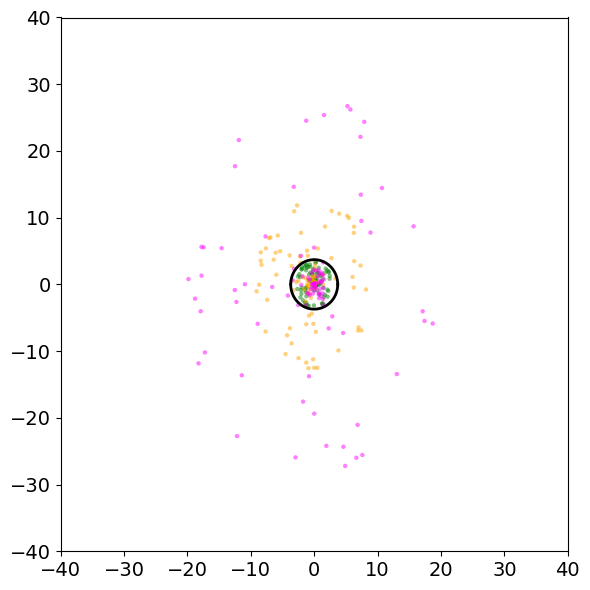

In [194]:
colors = ['cyan', 'green', 'orange', 'magenta', 'blue', 'red', 'purple']

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

for i, d in enumerate(data_list):
    ax.scatter(d['ReS_depol_SNR'], d['ImS_depol_SNR'],
               marker='o', facecolor=colors[i % len(colors)],
               edgecolor='none', s=10, alpha=0.5)

ax.set_xlim([-40, 40])
ax.set_ylim([-40, 40])
ax.tick_params(axis='both', labelsize=14)

x = np.linspace(-3.71, 3.71, 1000)
y = np.sqrt((1 - (x / 3.71)**2) * 3.71**2)
ax.plot(x,  y, c='black', linewidth=2)
ax.plot(x, -y, c='black', linewidth=2)

plt.tight_layout()

dpi = 600
plt.savefig('PCAS_DDAsim_oblate_DepolSNR_plots.jpg', dpi=dpi)

In [195]:
threshold = 13.82
for d in data_list:
    flag = d['Tot_depol_SNR2'] > threshold
    frac = np.count_nonzero(flag) / len(flag)
    print(f"  ind_rv={d['ind_rv']}  r_ve={d['r_ve']:.4f} um  NonSphere fraction = {frac:.4f}")

  ind_rv=0  r_ve=0.0999 um  NonSphere fraction = 0.0000
  ind_rv=1  r_ve=0.2027 um  NonSphere fraction = 0.0000
  ind_rv=2  r_ve=0.3065 um  NonSphere fraction = 0.5700
  ind_rv=3  r_ve=0.4095 um  NonSphere fraction = 0.5300


In [196]:
h5.close()